# Seasonal Ensemble Analysis

Analyses of the WY2021 seasonal forcing ensemble across 8 domains and 22 domain/model combinations.

**Sections:**
1. Load all summary CSVs and engineer columns
2. Variability metrics: normality testing, CV vs. QCD, ranking water balance metrics by variability
3. ET and subsurface storage by climate condition (warm/cool × wet/dry)
4. Spatial discretization vs. subsurface representation: which drives more ensemble spread?
5. Fall and spring snow accumulation signal (positive SWE change as a predictor)

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import product

os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

DATA_DIR = Path('/scratch/dlhogan/ess-project-data')
SEASONS   = ['fall', 'winter', 'spring', 'summer']
TRANS_SEASONS = ['fall', 'spring']   # seasons of interest for snow/ET analyses

# Domain registry: spatial structure and available subsurface models
DOMAIN_REGISTRY = {
    'East_River_lumped':                    {'basin': 'East_River',    'spatial': 'lumped',      'models': ['bigBuckt', 'noXplict']},
    'East_River_distributed':               {'basin': 'East_River',    'spatial': 'elev',        'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'East_River_distributed_elevAspect':    {'basin': 'East_River',    'spatial': 'elevAspect',  'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'East_River_distributed_elevTPI':       {'basin': 'East_River',    'spatial': 'elevTPI',     'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'Tuolumne_River_lumped':                {'basin': 'Tuolumne_River','spatial': 'lumped',      'models': ['bigBuckt', 'noXplict']},
    'Tuolumne_River_distributed_elev':      {'basin': 'Tuolumne_River','spatial': 'elev',        'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'Tuolumne_River_distributed_elevAspect':{'basin': 'Tuolumne_River','spatial': 'elevAspect',  'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
    'Tuolumne_River_distributed_elevTPI':   {'basin': 'Tuolumne_River','spatial': 'elevTPI',     'models': ['bigBuckt', 'noXplict', 'qTopmodl']},
}

SPATIAL_ORDER = ['lumped', 'elev', 'elevAspect', 'elevTPI']
MODEL_ORDER   = ['bigBuckt', 'noXplict', 'qTopmodl']
MODEL_COLORS  = {'bigBuckt': '#4878CF', 'noXplict': '#D65F5F', 'qTopmodl': '#6ACC65'}
BASIN_COLORS  = {'East_River': '#E07040', 'Tuolumne_River': '#7070CC'}

## 1. Load Summary CSVs

In [31]:
dfs = []
for domain, meta in DOMAIN_REGISTRY.items():
    ens_dir = DATA_DIR / f'domain_{domain}' / 'simulations' / 'seasonal_ensemble_simulations'
    for model in meta['models']:
        for season in SEASONS:
            csv = ens_dir / model / f'{season}_simulations' / 'summary.csv'
            if csv.exists():
                dfs.append(pd.read_csv(csv))

df = pd.concat(dfs, ignore_index=True)

# Engineer basin and spatial columns
df['basin']   = df['domain'].map({d: m['basin']   for d, m in DOMAIN_REGISTRY.items()})
df['spatial'] = df['domain'].map({d: m['spatial'] for d, m in DOMAIN_REGISTRY.items()})
df['spatial'] = pd.Categorical(df['spatial'], categories=SPATIAL_ORDER, ordered=True)
df['model']   = pd.Categorical(df['model'],   categories=MODEL_ORDER,   ordered=True)

print(f'Total rows: {len(df):,}')
print(f'Domains:    {df["domain"].nunique()}')
print(f'Models:     {df["model"].unique().tolist()}')
print(f'Seasons:    {df["season"].unique().tolist()}')
df.head(3)

Total rows: 1,760
Domains:    8
Models:     ['bigBuckt', 'noXplict', 'qTopmodl']
Seasons:    ['fall', 'winter', 'spring', 'summer']


,domain,model,season,donor_wy,total_q_mm,total_p_mm,runoff_ratio,total_et_sublim_mm,mean_aquifer_storage,mean_soil_liq_mm,mean_airtemp_C,total_snowfall_mm,pos_swe_change_mm,basin,spatial
0,East_River_lumped,bigBuckt,fall,2001,251.86,689.58,0.3652,377.22,0.1351,88.7477,2.033,445.72,338.85,East_River,lumped
1,East_River_lumped,bigBuckt,fall,2002,270.32,723.60,0.3736,382.04,0.1377,91.4362,2.529,472.26,356.33,East_River,lumped
2,East_River_lumped,bigBuckt,fall,2003,344.38,766.79,0.4491,386.49,0.1450,91.6478,2.119,514.74,407.15,East_River,lumped


## 2. Variability Metrics

First test normality (Shapiro-Wilk, n=20) per variable × season, then compute both parametric (CV) and non-parametric (QCD, NIQR, MAD) spread metrics across the 20 donor years.

| Metric | Formula | Notes |
|--------|---------|-------|
| CV | σ / μ | Parametric; assumes near-normal |
| QCD | (Q3−Q1)/(Q3+Q1) | Non-parametric analog to CV |
| NIQR | IQR / median | Simple; intuitive scale-free spread |
| MAD | median(\|xᵢ − median\|) | Most robust; not scale-free |

In [32]:
VARIABILITY_VARS = [
    ('total_q_mm',         'Total Q (mm)'),
    ('runoff_ratio',       'Runoff Ratio'),
    ('total_et_sublim_mm', 'ET + Sublim (mm)'),
    ('mean_soil_liq_mm',   'Mean Soil Liq (mm)'),
    ('mean_aquifer_storage','Mean Aquifer Storage (m)'),
    ('total_snowfall_mm',  'Total Snowfall (mm)'),
    ('pos_swe_change_mm',  'Positive SWE Change (mm)'),
]

def variability_metrics(x):
    """Compute variability metrics for a 1-D array x."""
    x = x.dropna()
    if len(x) < 4:
        return pd.Series({'n': len(x), 'cv': np.nan, 'qcd': np.nan,
                          'niqr': np.nan, 'mad': np.nan, 'sw_p': np.nan})
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    med = np.median(x)
    mu  = np.mean(x)
    sw_stat, sw_p = stats.shapiro(x)
    return pd.Series({
        'n'    : len(x),
        'mean' : mu,
        'cv'   : x.std() / mu if mu != 0 else np.nan,
        'qcd'  : (q3 - q1) / (q3 + q1) if (q3 + q1) != 0 else np.nan,
        'niqr' : iqr / med if med != 0 else np.nan,
        'mad'  : np.median(np.abs(x - med)),
        'sw_p' : sw_p,          # < 0.05 → reject normality
    })

rows = []
for varname, varlabel in VARIABILITY_VARS:
    if varname not in df.columns:
        continue
    for (basin, season, model), grp in df.groupby(['basin', 'season', 'model'], observed=True):
        m = variability_metrics(grp[varname])
        m['variable'] = varname
        m['label']    = varlabel
        m['basin']    = basin
        m['season']   = season
        m['model']    = model
        rows.append(m)

vm = pd.DataFrame(rows)
vm['normal'] = vm['sw_p'] > 0.05   # True = cannot reject normality
print(f'Fraction normally distributed (SW p>0.05): {vm["normal"].mean():.1%}')
print()
print('Normality by variable:')
vm.groupby('variable')['normal'].mean().sort_values().to_frame()

Fraction normally distributed (SW p>0.05): 32.1%

Normality by variable:


/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/hom

,normal
variable,
total_et_sublim_mm,0.000000
mean_soil_liq_mm,0.041667
runoff_ratio,0.250000
total_q_mm,0.375000
total_snowfall_mm,0.458333
pos_swe_change_mm,0.458333
mean_aquifer_storage,0.666667


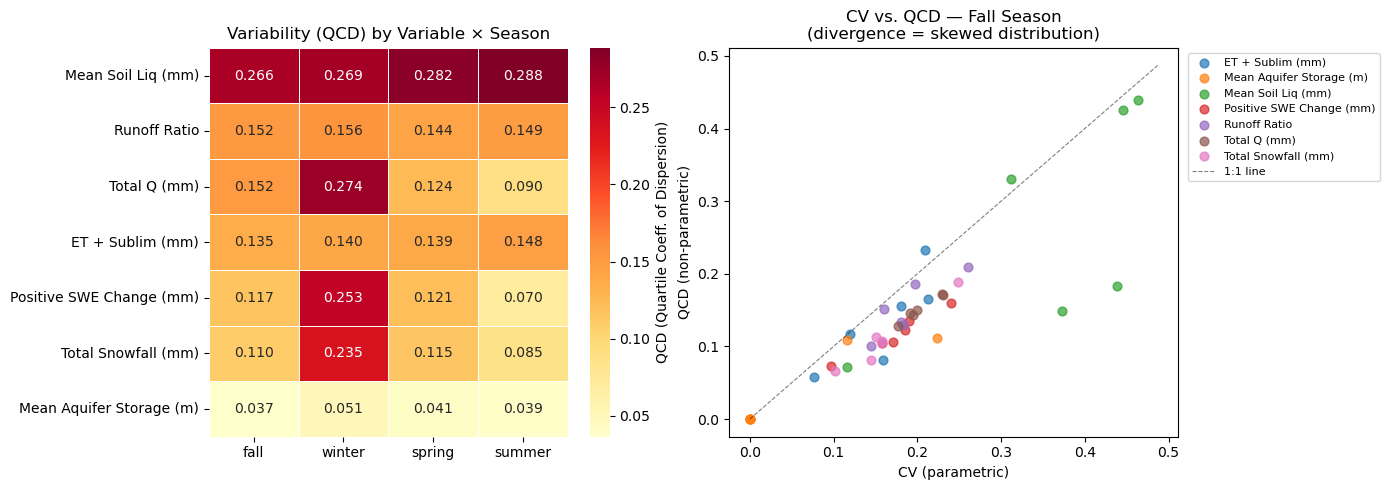

In [4]:
# Mean QCD per variable × season (averaged across domains/models)
qcd_pivot = (
    vm.groupby(['label', 'season'])['qcd']
    .mean()
    .unstack('season')[SEASONS]
    .sort_values('fall', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of QCD
sns.heatmap(
    qcd_pivot, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.3f',
    linewidths=0.5, cbar_kws={'label': 'QCD (Quartile Coeff. of Dispersion)'}
)
axes[0].set_title('Variability (QCD) by Variable × Season')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# CV vs QCD scatter — where they diverge, distribution is skewed
vm_fall = vm[vm['season'] == 'fall'].dropna(subset=['cv', 'qcd'])
for label, grp in vm_fall.groupby('label'):
    axes[1].scatter(grp['cv'], grp['qcd'], label=label, alpha=0.7, s=40)
lim = max(vm_fall[['cv','qcd']].max().max() * 1.05, 0.3)
axes[1].plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='1:1 line')
axes[1].set_xlabel('CV (parametric)')
axes[1].set_ylabel('QCD (non-parametric)')
axes[1].set_title('CV vs. QCD — Fall Season\n(divergence = skewed distribution)')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

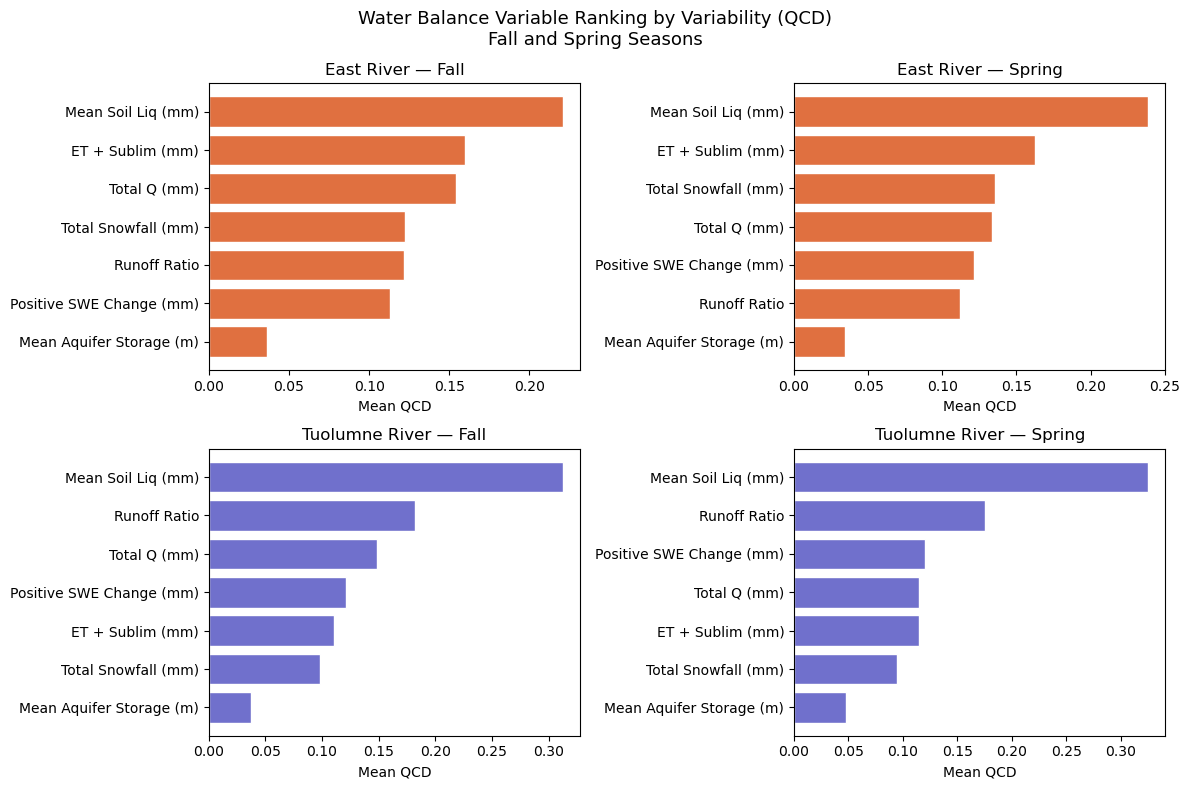

In [8]:
# Rank variables by QCD within each basin × season for fall and spring
rank_df = (
    vm[vm['season'].isin(TRANS_SEASONS)]
    .groupby(['basin', 'season', 'variable', 'label'])['qcd']
    .mean().reset_index()
    .sort_values(['basin', 'season', 'qcd'], ascending=[True, True, False])
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for ax, (basin, season) in zip(axes.flat, product(['East_River', 'Tuolumne_River'], TRANS_SEASONS)):
    sub = rank_df[(rank_df['basin'] == basin) & (rank_df['season'] == season)]
    ax.barh(sub['label'], sub['qcd'], color=BASIN_COLORS[basin], edgecolor='white')
    ax.set_xlabel('Mean QCD')
    ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
    ax.invert_yaxis()

plt.suptitle('Water Balance Variable Ranking by Variability (QCD)\nFall and Spring Seasons', fontsize=13)
plt.tight_layout()
plt.show()

## 3. ET and Subsurface Storage by Climate Condition

Classify each donor year within each basin × season group into four climate conditions using percentile-based thresholds:
- **Temperature**: `mean_airtemp_C` — < 25th = cool, > 75th = warm, otherwise normal  
- **Precipitation**: `total_p_mm` — < 25th = dry, > 75th = wet, otherwise normal  
- Labels: `warm-wet`, `warm-dry`, `cool-wet`, `cool-dry`, `normal` (middle 50th)

Classification uses thresholds from the forcing data embedded in each run (airtemp and pptrate stored in SUMMA output).

In [34]:
def classify_climate(grp, temp_col='mean_airtemp_C', ppt_col='total_p_mm'):
    """Assign warm/cool and wet/dry labels using 25th/75th percentile thresholds."""
    grp = grp.copy()
    t25, t75 = grp[temp_col].quantile([0.25, 0.75])
    p25, p75 = grp[ppt_col].quantile([0.25, 0.75])

    def label(row):
        t = 'warm' if row[temp_col] > t75 else ('cool' if row[temp_col] < t25 else 'normal_T')
        p = 'wet'  if row[ppt_col]  > p75 else ('dry'  if row[ppt_col]  < p25 else 'normal_P')
        if 'normal' in t or 'normal' in p:
            return 'normal'
        return f'{t}-{p}'

    grp['climate'] = grp.apply(label, axis=1)
    return grp

# Apply classification: percentiles computed per basin × season group
# Use one representative model per group since forcing is identical across models
ref_model = 'bigBuckt'
clim_keys = df[df['model'] == ref_model].groupby(
    ['basin', 'season', 'donor_wy'], observed=True
)[['mean_airtemp_C', 'total_p_mm']].first().reset_index()

clim_keys = (
    clim_keys.groupby(['basin', 'season'], observed=True, group_keys=False)
    .apply(classify_climate)
)

df = df.merge(clim_keys[['basin', 'season', 'donor_wy', 'climate']],
              on=['basin', 'season', 'donor_wy'], how='left')

print('Climate condition counts (fall):')
print(df[df['season']=='fall'].groupby(['basin','climate']).size().unstack(fill_value=0))

Climate condition counts (fall):
climate         cool-dry  cool-wet  normal  warm-dry
basin                                               
East_River            11        11     154        44
Tuolumne_River         0        22     176        22


/tmp/ipykernel_1653832/494102174.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify_climate)


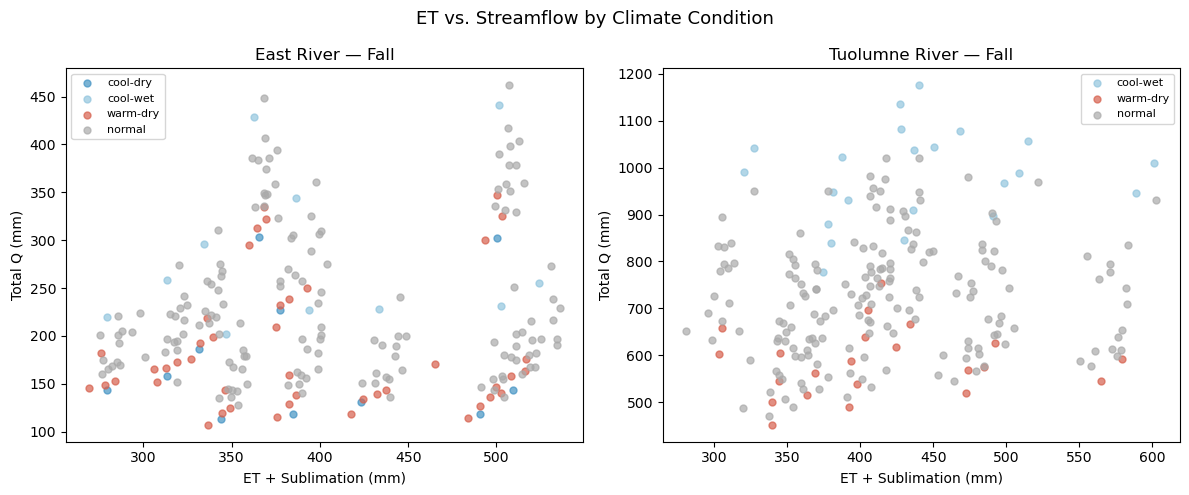

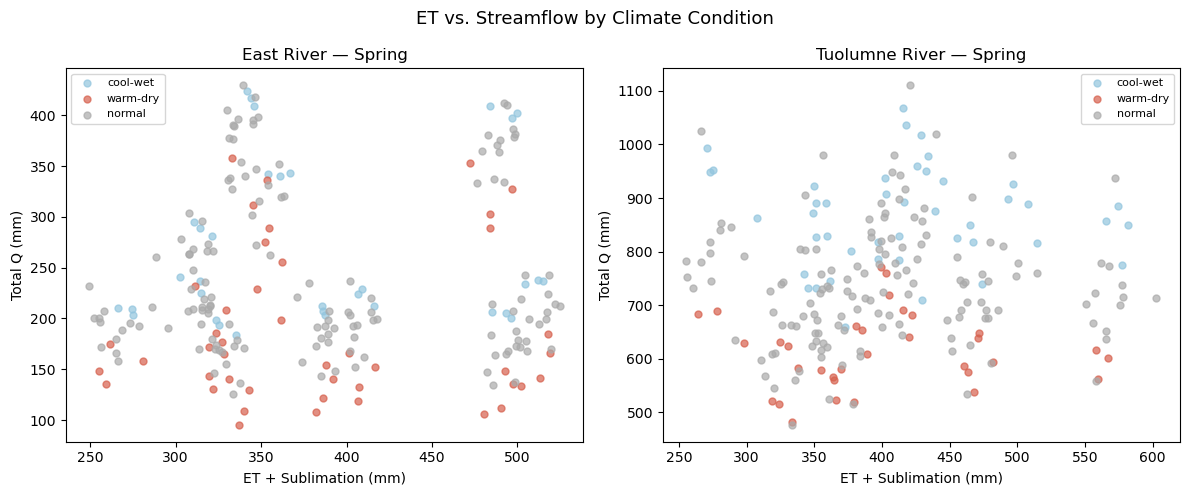

In [35]:
# 2-D scatter: ET vs. Q colored by climate condition, for fall and spring
for season in TRANS_SEASONS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, basin in zip(axes, ['East_River', 'Tuolumne_River']):
        sub = df[(df['basin'] == basin) & (df['season'] == season)].dropna(
            subset=['total_et_sublim_mm', 'total_q_mm', 'climate'])
        for clim in CLIM_ORDER:
            c = sub[sub['climate'] == clim]
            if c.empty:
                continue
            ax.scatter(c['total_et_sublim_mm'], c['total_q_mm'],
                       color=CLIM_COLORS[clim], label=clim, alpha=0.7, s=25)
        ax.set_xlabel('ET + Sublimation (mm)')
        ax.set_ylabel('Total Q (mm)')
        ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
        ax.legend(fontsize=8)
    plt.suptitle('ET vs. Streamflow by Climate Condition', fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Spatial Discretization vs. Subsurface Representation

**Question:** Which provides more "bang for the buck" in terms of ensemble spread — spatial discretization (lumped → elev → elevAspect → elevTPI) or subsurface representation (bigBuckt → noXplict → qTopmodl)?

**Approach:** For each basin × season × target variable, compute the ensemble IQR (across 20 donor years) for every domain/model combination. Then:
- **σ_spatial**: std of ensemble IQR across the 4 spatial levels (holding model fixed, for models common to all spatial levels)
- **σ_subsurface**: std of ensemble IQR across the 3 subsurface models (holding spatial fixed at distributed level)

In [36]:
TARGET_VARS = [
    ('total_q_mm',        'Total Q (mm)'),
    ('runoff_ratio',      'Runoff Ratio'),
    ('total_et_sublim_mm','ET + Sublim (mm)'),
    ('mean_soil_liq_mm',  'Mean Soil Liq (mm)'),
]

def ensemble_iqr(x):
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)

# Compute ensemble IQR for each domain × model × season
iqr_df = (
    df.groupby(['basin', 'spatial', 'model', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .agg(ensemble_iqr)
    .reset_index()
)

# --- Spatial variance: fix model, vary spatial (using models common to all spatial levels)
COMMON_MODELS = ['bigBuckt', 'noXplict']   # available at lumped and distributed
spatial_var = (
    iqr_df[iqr_df['model'].isin(COMMON_MODELS)]
    .groupby(['basin', 'model', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .std()
    .reset_index()
    .melt(id_vars=['basin', 'model', 'season'], var_name='variable', value_name='sigma')
)
spatial_var['dimension'] = 'Spatial'

# --- Subsurface variance: fix spatial (distributed), vary subsurface model
DIST_SPATIALS = ['elev', 'elevAspect', 'elevTPI']   # distributed only (qTopmodl not in lumped)
sub_var = (
    iqr_df[iqr_df['spatial'].isin(DIST_SPATIALS)]
    .groupby(['basin', 'spatial', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .std()
    .reset_index()
    .melt(id_vars=['basin', 'spatial', 'season'], var_name='variable', value_name='sigma')
)
sub_var['dimension'] = 'Subsurface'

decomp = pd.concat([
    spatial_var.rename(columns={'model': 'group'}),
    sub_var.rename(columns={'spatial': 'group'})
], ignore_index=True)

# Mean sigma across groups within each basin × season × variable × dimension
decomp_mean = decomp.groupby(['basin', 'season', 'variable', 'dimension'])['sigma'].mean().reset_index()
decomp_mean['label'] = decomp_mean['variable'].map(dict(TARGET_VARS))

decomp_mean.head()

,basin,season,variable,dimension,sigma,label
0,East_River,fall,mean_soil_liq_mm,Spatial,5.894210,Mean Soil Liq (mm)
1,East_River,fall,mean_soil_liq_mm,Subsurface,14.788263,Mean Soil Liq (mm)
2,East_River,fall,runoff_ratio,Spatial,0.005253,Runoff Ratio
3,East_River,fall,runoff_ratio,Subsurface,0.004150,Runoff Ratio
4,East_River,fall,total_et_sublim_mm,Spatial,3.388558,ET + Sublim (mm)


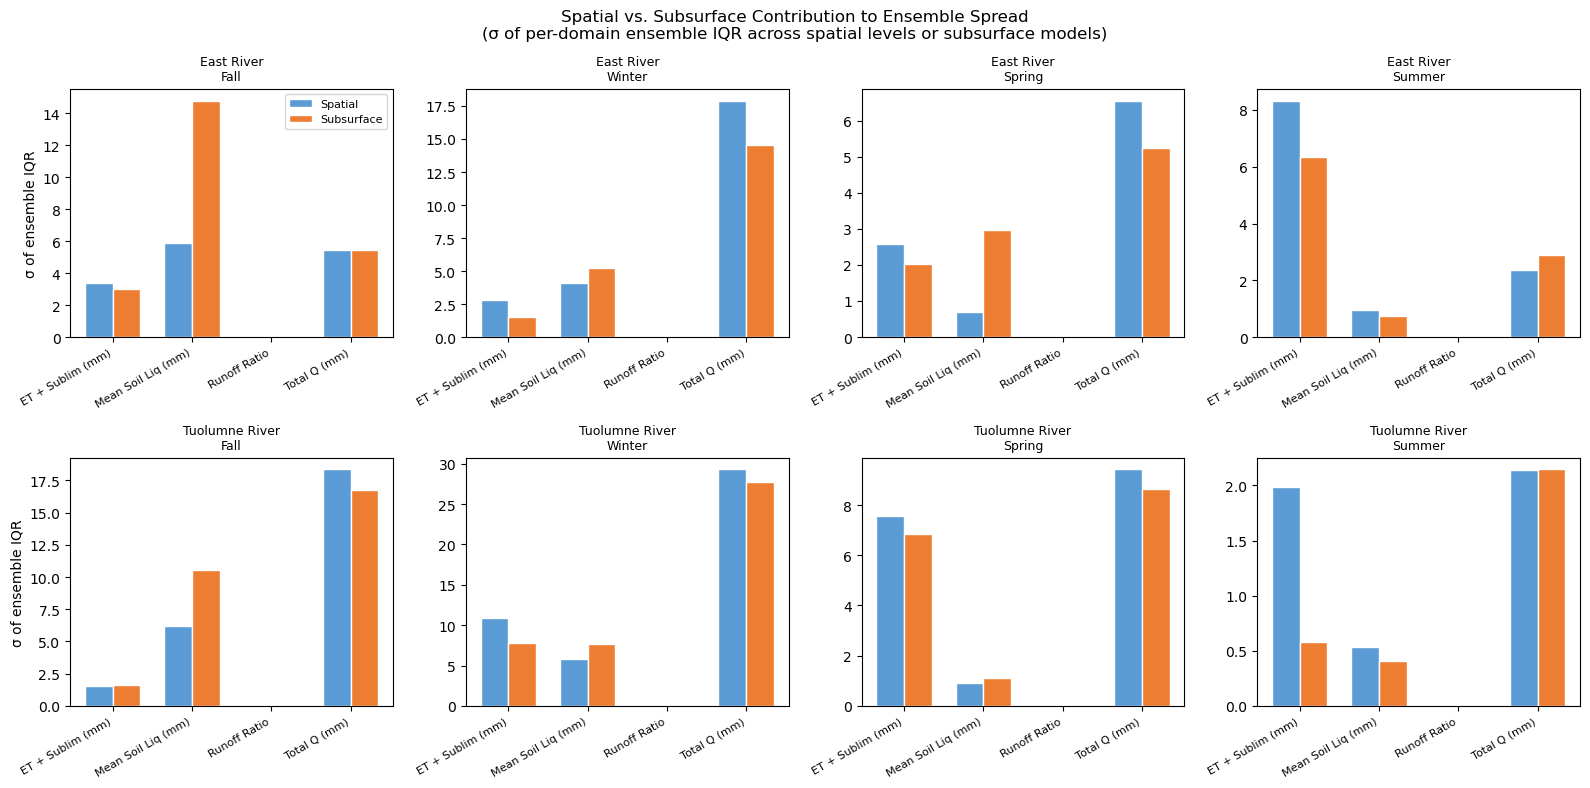

In [37]:
# Plot: σ_spatial vs. σ_subsurface for each basin × season
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)

for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, season in enumerate(SEASONS):
        ax = axes[row_i, col_i]
        sub = decomp_mean[(decomp_mean['basin'] == basin) & (decomp_mean['season'] == season)]
        pivot = sub.pivot(index='label', columns='dimension', values='sigma')
        x = np.arange(len(pivot))
        w = 0.35
        ax.bar(x - w/2, pivot.get('Spatial',    pd.Series(dtype=float)), w,
               label='Spatial', color='#5A9BD5', edgecolor='white')
        ax.bar(x + w/2, pivot.get('Subsurface', pd.Series(dtype=float)), w,
               label='Subsurface', color='#ED7D31', edgecolor='white')
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=8)
        ax.set_title(f'{basin.replace("_"," ")}\n{season.capitalize()}', fontsize=9)
        ax.set_ylabel('σ of ensemble IQR' if col_i == 0 else '')
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=8)

plt.suptitle('Spatial vs. Subsurface Contribution to Ensemble Spread\n'
             '(σ of per-domain ensemble IQR across spatial levels or subsurface models)', fontsize=12)
plt.tight_layout()
plt.show()

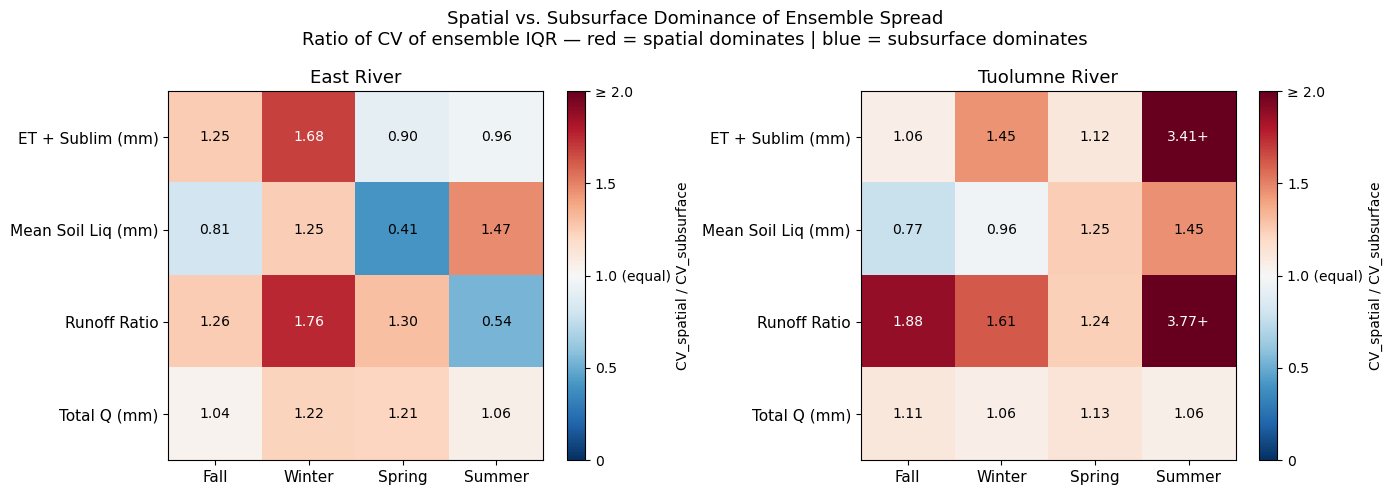

In [38]:
# Ratio of CV: CV_spatial / CV_subsurface
# CV_spatial   = std(IQR across 4 spatial levels) / mean(IQR), averaged across common models
# CV_subsurface = std(IQR across 3 subsurface models) / mean(IQR), averaged across distributed spatials
# Ratio > 1 → spatial choice drives more *relative* variability; < 1 → subsurface model does.
# Linear scale (not log), centered at 1; annotated values clipped to 3 for display.

def cv_of_group(x):
    """CV of a set of IQR values across configurations (how much does IQR vary?)."""
    x = x.dropna()
    mu = x.mean()
    return x.std() / mu if (mu > 0 and len(x) > 1) else np.nan

spatial_cv = (
    iqr_df[iqr_df['model'].isin(COMMON_MODELS)]
    .groupby(['basin', 'model', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .agg(cv_of_group)
    .reset_index()
    .melt(id_vars=['basin', 'model', 'season'], var_name='variable', value_name='cv')
    .groupby(['basin', 'season', 'variable'], observed=True)['cv']
    .mean()
    .reset_index(name='cv_spatial')
)

sub_cv = (
    iqr_df[iqr_df['spatial'].isin(DIST_SPATIALS)]
    .groupby(['basin', 'spatial', 'season'], observed=True)
    [[v for v, _ in TARGET_VARS]]
    .agg(cv_of_group)
    .reset_index()
    .melt(id_vars=['basin', 'spatial', 'season'], var_name='variable', value_name='cv')
    .groupby(['basin', 'season', 'variable'], observed=True)['cv']
    .mean()
    .reset_index(name='cv_subsurface')
)

ratio_cv = spatial_cv.merge(sub_cv, on=['basin', 'season', 'variable'])
ratio_cv['ratio'] = ratio_cv['cv_spatial'] / ratio_cv['cv_subsurface']
ratio_cv['label'] = ratio_cv['variable'].map(dict(TARGET_VARS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, basin in zip(axes, ['East_River', 'Tuolumne_River']):
    sub = ratio_cv[ratio_cv['basin'] == basin]
    pivot = sub.pivot_table(index='label', columns='season', values='ratio')[SEASONS]
    display_vals = pivot.clip(upper=3.0)
    im = ax.imshow(display_vals.values, cmap='RdBu_r', vmin=0, vmax=2, aspect='auto')
    ax.set_xticks(range(len(SEASONS)))
    ax.set_xticklabels([s.capitalize() for s in SEASONS], fontsize=11)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=11)
    ax.set_title(f'{basin.replace("_", " ")}', fontsize=13)
    for i in range(len(pivot)):
        for j in range(len(SEASONS)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                txt = f'{val:.2f}' + ('+' if val > 3.0 else '')
                bg = display_vals.values[i, j]
                ax.text(j, i, txt, ha='center', va='center', fontsize=10,
                        color='white' if abs(bg - 1) > 0.65 else 'black')
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('CV_spatial / CV_subsurface', fontsize=10)
    cb.set_ticks([0, 0.5, 1.0, 1.5, 2.0])
    cb.set_ticklabels(['0', '0.5', '1.0 (equal)', '1.5', '≥ 2.0'])

plt.suptitle('Spatial vs. Subsurface Dominance of Ensemble Spread\n'
             'Ratio of CV of ensemble IQR — red = spatial dominates | blue = subsurface dominates',
             fontsize=13)
plt.tight_layout()
plt.show()


## 5. Snow Accumulation as a Variability Signal

For fall and spring, is **positive SWE change** (net snow accumulation over the season) a strong predictor of seasonal streamflow variability? This captures the warm/cool signal more physically than temperature alone — a cool donor year accumulates snow; a warm year does not.

We also compare predictive power of `pos_swe_change_mm` against `mean_airtemp_C` and `total_p_mm`.

In [39]:
from scipy.stats import pearsonr, spearmanr

PREDICTORS = [
    ('pos_swe_change_mm', 'Positive SWE Change (mm)'),
    ('mean_airtemp_C',    'Mean Air Temp (°C)'),
    ('total_p_mm',        'Total Precip (mm)'),
]
RESPONSES = [
    ('total_q_mm',        'Total Q (mm)'),
    ('total_et_sublim_mm','ET + Sublim (mm)'),
    ('mean_soil_liq_mm',  'Mean Soil Liq (mm)'),
]

corr_rows = []
for (basin, season, model), grp in df[df['season'].isin(TRANS_SEASONS)].groupby(
        ['basin', 'season', 'model'], observed=True):
    for pred_col, pred_label in PREDICTORS:
        for resp_col, resp_label in RESPONSES:
            sub = grp[[pred_col, resp_col]].dropna()
            if len(sub) < 6:
                continue
            r_pearson,  p_pearson  = pearsonr(sub[pred_col],  sub[resp_col])
            r_spearman, p_spearman = spearmanr(sub[pred_col], sub[resp_col])
            corr_rows.append({
                'basin': basin, 'season': season, 'model': model,
                'predictor': pred_label, 'response': resp_label,
                'r_pearson': r_pearson, 'r_spearman': r_spearman,
                'p_pearson': p_pearson, 'p_spearman': p_spearman,
            })

corr_df = pd.DataFrame(corr_rows)

# Mean |Spearman r| by predictor × response — averaged across models
corr_mean = (
    corr_df.groupby(['basin', 'season', 'predictor', 'response'])['r_spearman']
    .mean().reset_index()
)
corr_mean.head()

,basin,season,predictor,response,r_spearman
0,East_River,fall,Mean Air Temp (°C),ET + Sublim (mm),0.335754
1,East_River,fall,Mean Air Temp (°C),Mean Soil Liq (mm),0.073349
2,East_River,fall,Mean Air Temp (°C),Total Q (mm),-0.065579
3,East_River,fall,Positive SWE Change (mm),ET + Sublim (mm),0.278045
4,East_River,fall,Positive SWE Change (mm),Mean Soil Liq (mm),0.449964


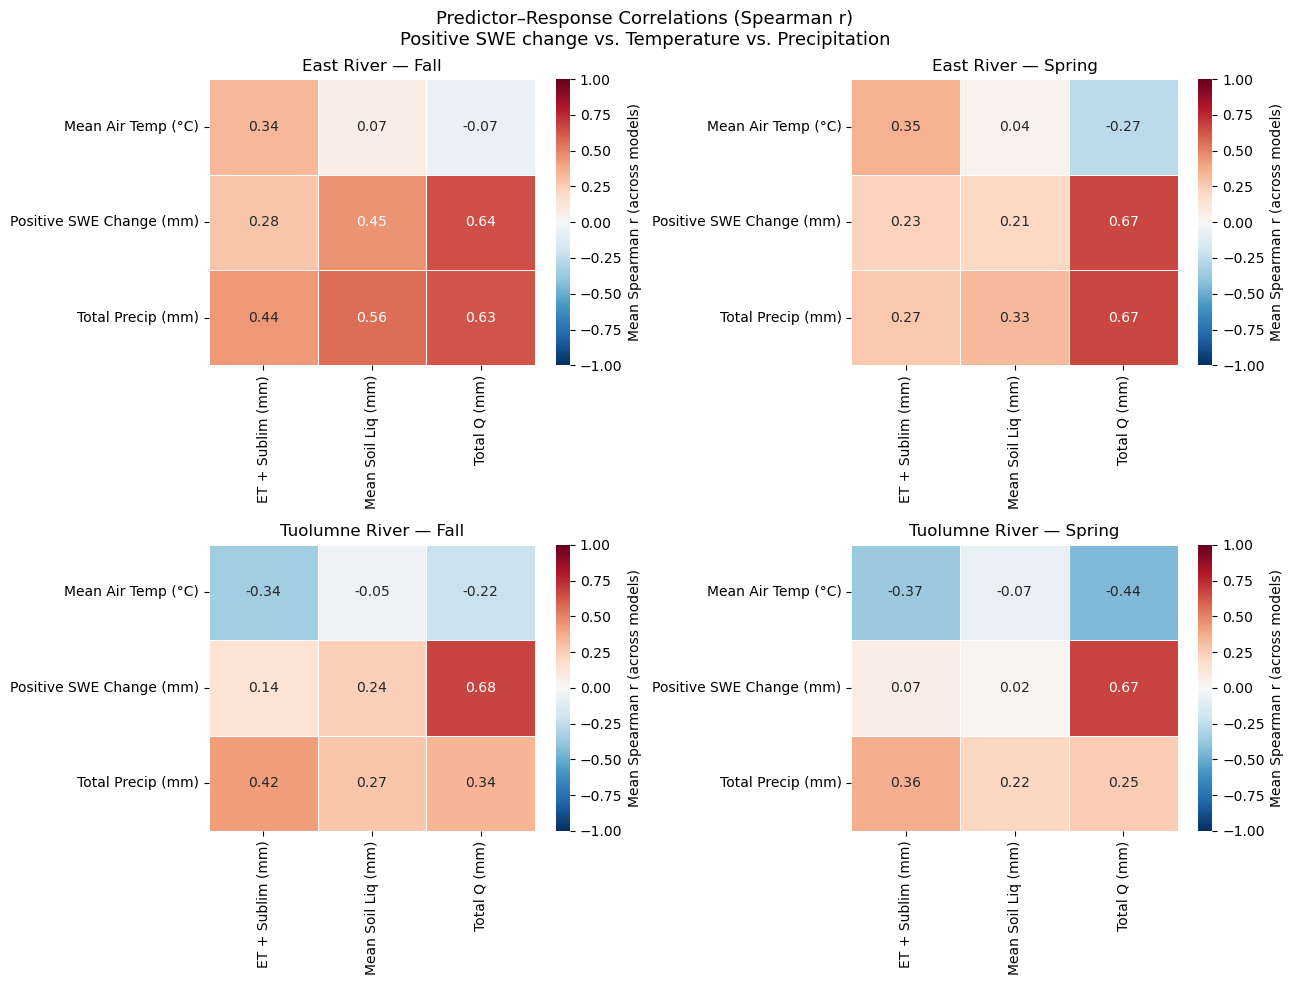

In [40]:
# Heatmap: mean Spearman r for each predictor × response, for fall and spring
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (basin, season) in zip(axes.flat, product(['East_River', 'Tuolumne_River'], TRANS_SEASONS)):
    sub = corr_mean[(corr_mean['basin'] == basin) & (corr_mean['season'] == season)]
    pivot = sub.pivot(index='predictor', columns='response', values='r_spearman')
    sns.heatmap(
        pivot, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', linewidths=0.5,
        cbar_kws={'label': 'Mean Spearman r (across models)'}
    )
    ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Predictor–Response Correlations (Spearman r)\n'
             'Positive SWE change vs. Temperature vs. Precipitation', fontsize=13)
plt.tight_layout()
plt.show()

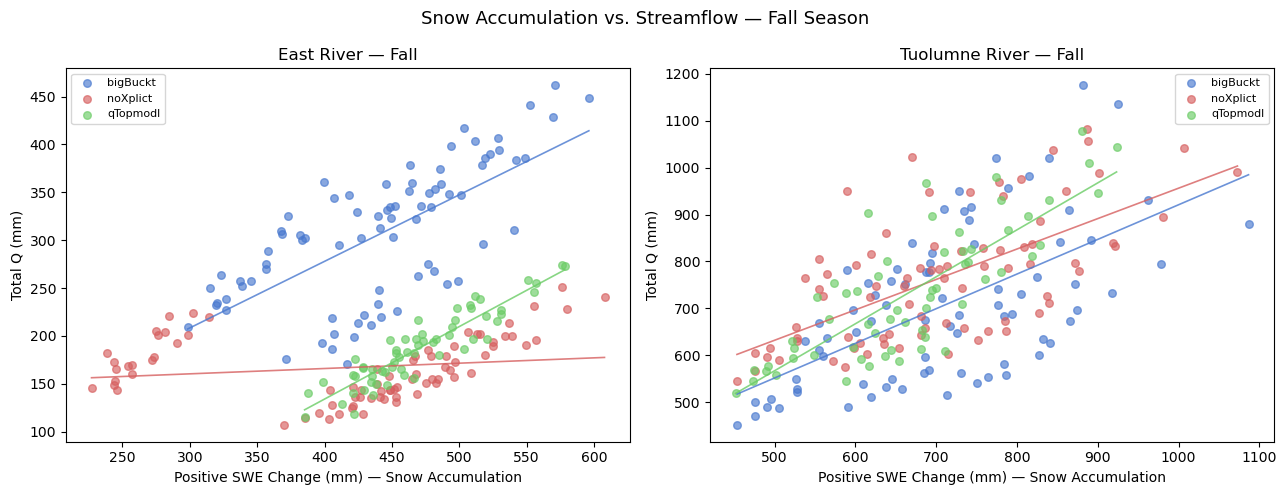

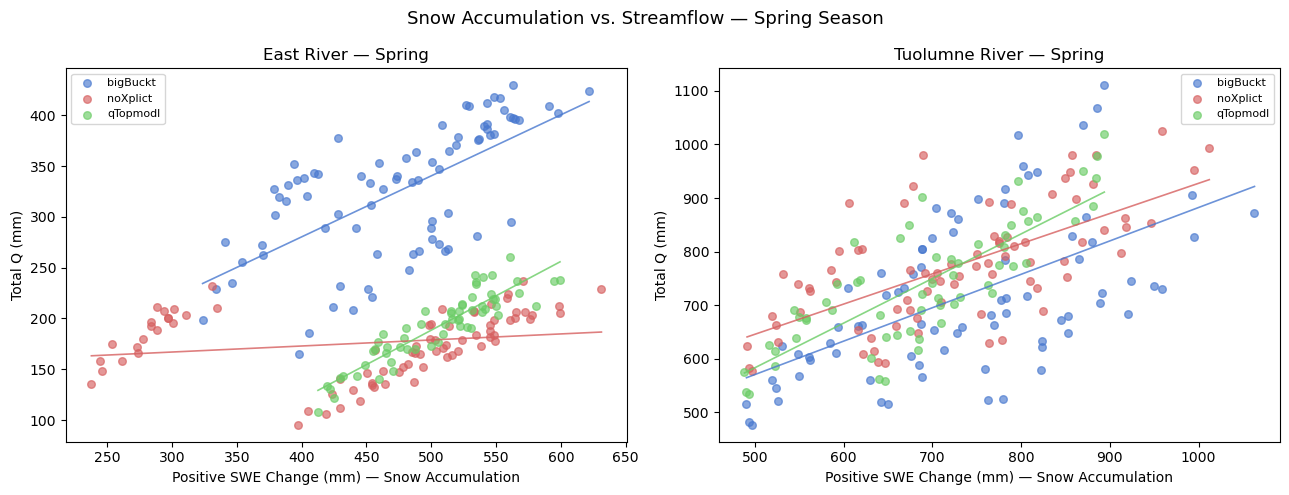

In [41]:
# Scatter: pos_swe_change_mm vs. total_q_mm for fall and spring, colored by model
for season in TRANS_SEASONS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, basin in zip(axes, ['East_River', 'Tuolumne_River']):
        sub = df[(df['basin'] == basin) & (df['season'] == season)].dropna(
            subset=['pos_swe_change_mm', 'total_q_mm'])
        for model in MODEL_ORDER:
            m = sub[sub['model'] == model]
            if m.empty:
                continue
            ax.scatter(m['pos_swe_change_mm'], m['total_q_mm'],
                       color=MODEL_COLORS[model], label=model, alpha=0.65, s=30)
            # regression line per model
            x, y = m['pos_swe_change_mm'], m['total_q_mm']
            if len(x) > 3:
                xfit = np.linspace(x.min(), x.max(), 50)
                slope, intercept, *_ = stats.linregress(x, y)
                ax.plot(xfit, slope * xfit + intercept,
                        color=MODEL_COLORS[model], lw=1.2, alpha=0.8)
        ax.set_xlabel('Positive SWE Change (mm) — Snow Accumulation')
        ax.set_ylabel('Total Q (mm)')
        ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
        ax.legend(fontsize=8)
    plt.suptitle(f'Snow Accumulation vs. Streamflow — {season.capitalize()} Season', fontsize=13)
    plt.tight_layout()
    plt.show()

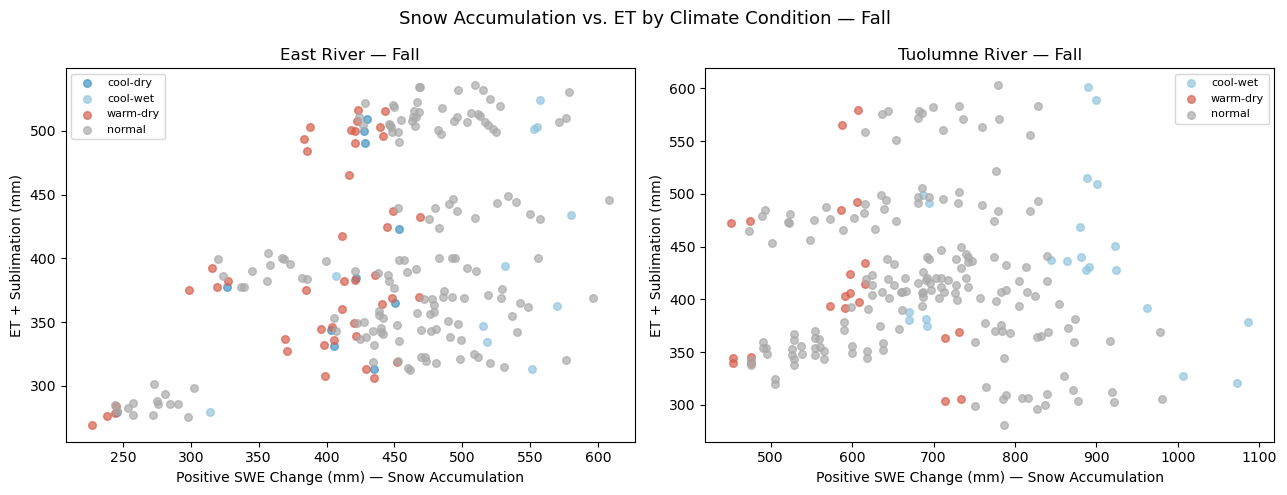

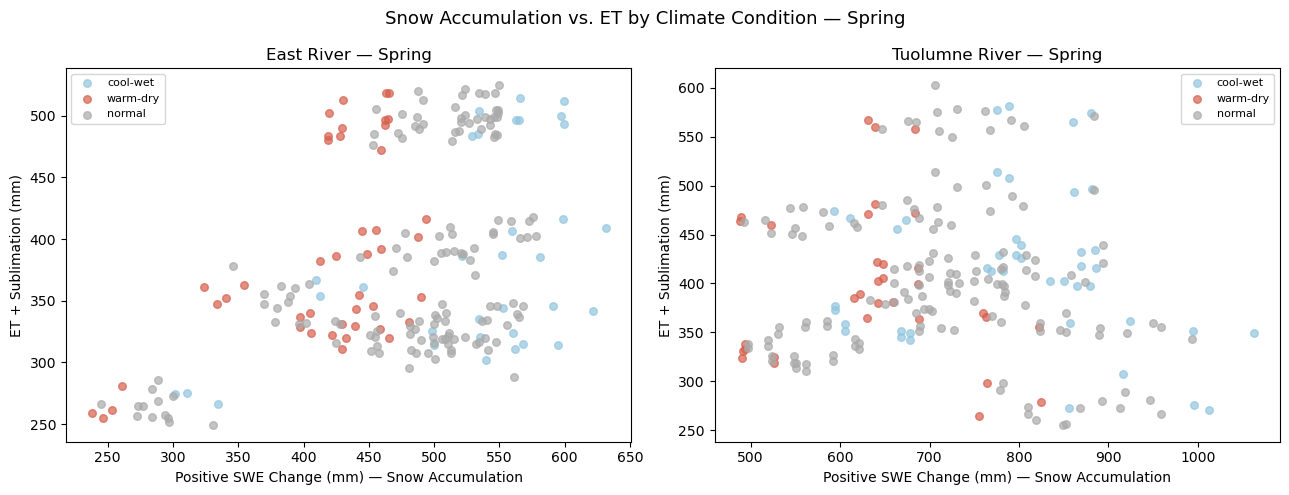

In [42]:
# Scatter: pos_swe_change_mm vs. ET, colored by climate condition
for season in TRANS_SEASONS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, basin in zip(axes, ['East_River', 'Tuolumne_River']):
        sub = df[(df['basin'] == basin) & (df['season'] == season)].dropna(
            subset=['pos_swe_change_mm', 'total_et_sublim_mm', 'climate'])
        for clim in CLIM_ORDER:
            c = sub[sub['climate'] == clim]
            if c.empty:
                continue
            ax.scatter(c['pos_swe_change_mm'], c['total_et_sublim_mm'],
                       color=CLIM_COLORS[clim], label=clim, alpha=0.7, s=30)
        ax.set_xlabel('Positive SWE Change (mm) — Snow Accumulation')
        ax.set_ylabel('ET + Sublimation (mm)')
        ax.set_title(f'{basin.replace("_"," ")} — {season.capitalize()}')
        ax.legend(fontsize=8)
    plt.suptitle(f'Snow Accumulation vs. ET by Climate Condition — {season.capitalize()}', fontsize=13)
    plt.tight_layout()
    plt.show()

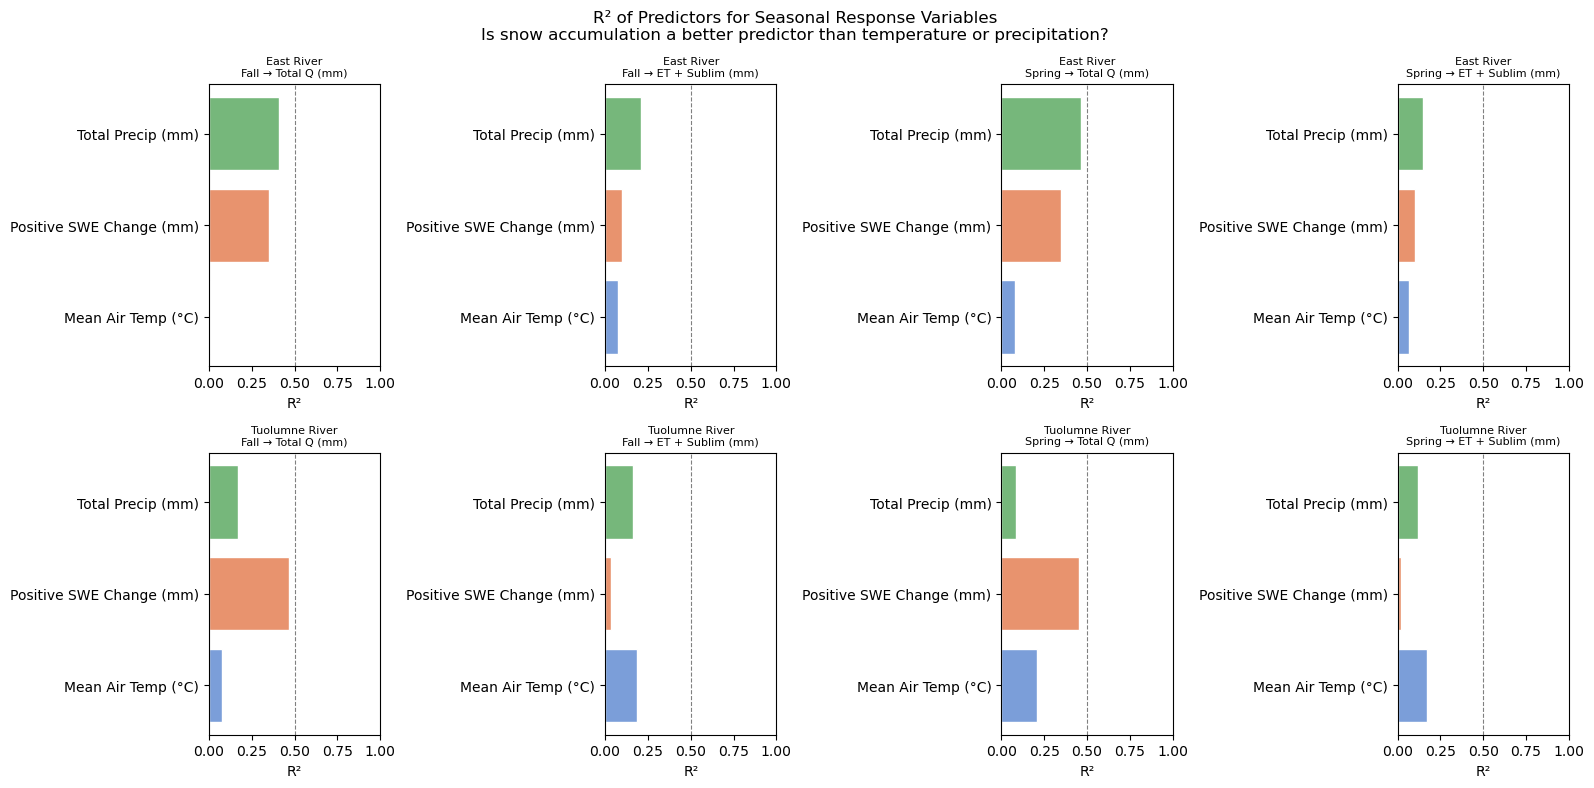

In [43]:
# Summary: R² comparison across predictors for each basin × season × response
r2_summary = (
    corr_df[corr_df['season'].isin(TRANS_SEASONS)]
    .groupby(['basin', 'season', 'predictor', 'response'])['r_pearson']
    .mean()
    .apply(lambda r: r**2)
    .reset_index()
    .rename(columns={'r_pearson': 'R2'})
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, (season, response) in enumerate(product(TRANS_SEASONS, ['Total Q (mm)', 'ET + Sublim (mm)'])):
        ax = axes[row_i, col_i]
        sub = r2_summary[(r2_summary['basin'] == basin) &
                         (r2_summary['season'] == season) &
                         (r2_summary['response'] == response)]
        colors = ['#7B9ED9', '#E8936E', '#76B77B']
        ax.barh(sub['predictor'], sub['R2'], color=colors[:len(sub)], edgecolor='white')
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color='gray', lw=0.8, ls='--')
        ax.set_xlabel('R²')
        ax.set_title(f'{basin.replace("_"," ")}\n{season.capitalize()} → {response}', fontsize=8)

plt.suptitle('R² of Predictors for Seasonal Response Variables\n'
             'Is snow accumulation a better predictor than temperature or precipitation?', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1653832/3341534601.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='spatial', columns='model', values='cv')
/tmp/ipykernel_1653832/3341534601.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='spatial', columns='model', values='cv')
/tmp/ipykernel_1653832/3341534601.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='spatial', columns='model', values='cv')
/tmp/ipykernel_1653832/3341534601.

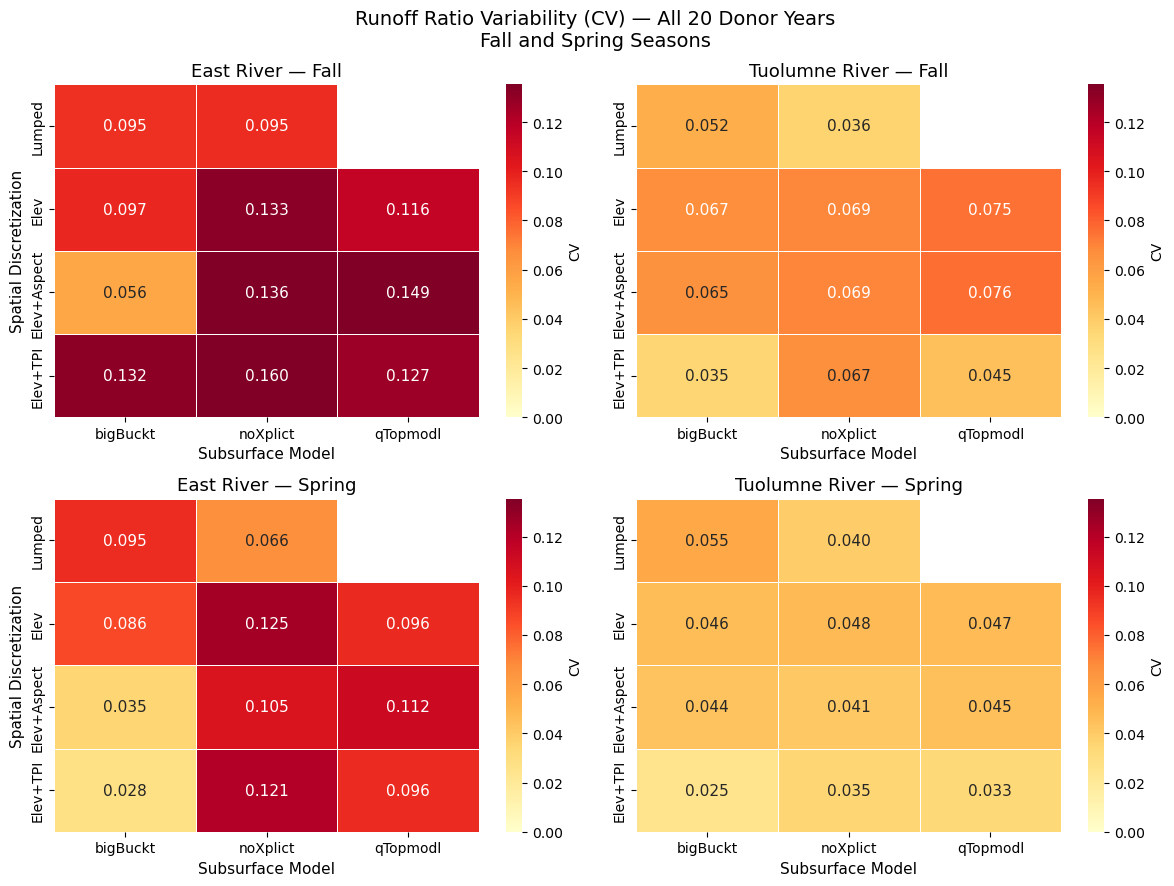

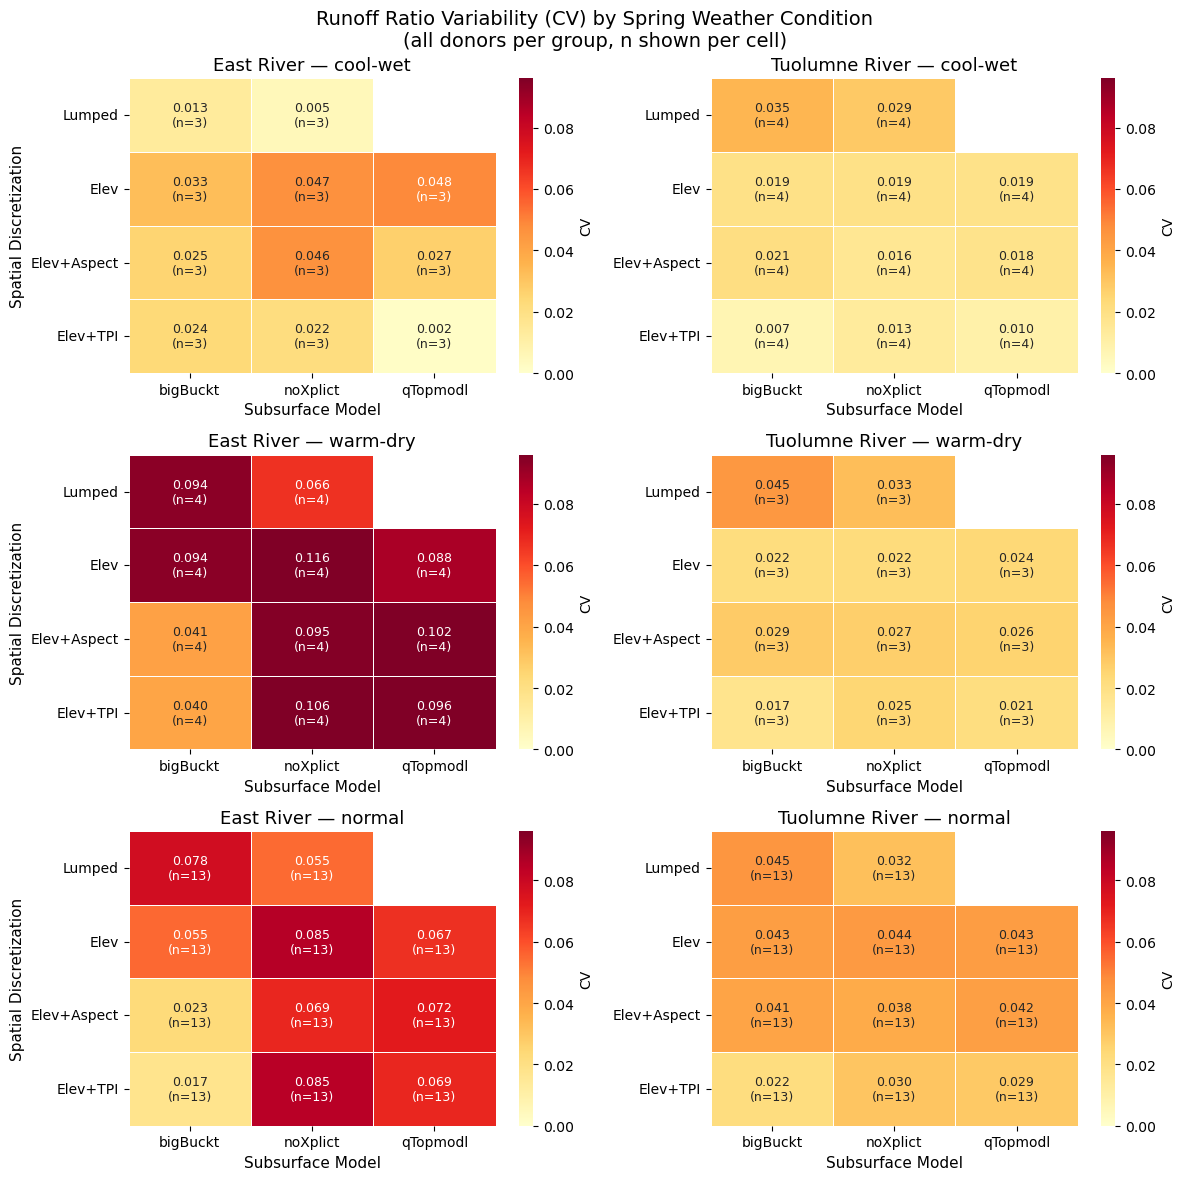

In [44]:

# ============================================================
# 6. Runoff Ratio Variability (CV) by Spatial × Subsurface Model
# ============================================================
# CV of seasonal runoff_ratio across 20 donor years.
# Layout: 2 rows (fall, spring) × 2 cols (East River, Tuolumne)
# Each panel: heatmap — y = spatial discretization, x = subsurface model

SPATIAL_LABELS = {
    'lumped': 'Lumped', 'elev': 'Elev',
    'elevAspect': 'Elev+Aspect', 'elevTPI': 'Elev+TPI',
}

cv_rr = (
    df[df['season'].isin(['fall', 'spring'])]
    .groupby(['basin', 'spatial', 'model', 'season'], observed=True)['runoff_ratio']
    .agg(lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan)
    .reset_index(name='cv')
)

vmax_all = cv_rr['cv'].quantile(0.95)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row_i, season in enumerate(['fall', 'spring']):
    for col_i, basin in enumerate(['East_River', 'Tuolumne_River']):
        ax = axes[row_i, col_i]
        sub = cv_rr[(cv_rr['basin'] == basin) & (cv_rr['season'] == season)]
        pivot = sub.pivot_table(index='spatial', columns='model', values='cv')
        spatial_avail = [s for s in SPATIAL_ORDER if s in pivot.index]
        model_avail   = [m for m in MODEL_ORDER if m in pivot.columns]
        pivot = pivot.reindex(index=spatial_avail, columns=model_avail)
        pivot.index = [SPATIAL_LABELS[s] for s in spatial_avail]
        sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
                    linewidths=0.5, vmin=0, vmax=vmax_all,
                    cbar_kws={'label': 'CV'}, annot_kws={'size': 11})
        ax.set_title(f'{basin.replace("_", " ")} — {season.capitalize()}', fontsize=13)
        ax.set_xlabel('Subsurface Model', fontsize=11)
        ax.set_ylabel('Spatial Discretization' if col_i == 0 else '', fontsize=11)
        ax.tick_params(labelsize=10)

plt.suptitle('Runoff Ratio Variability (CV) — All 20 Donor Years\nFall and Spring Seasons', fontsize=14)
plt.tight_layout()
plt.savefig('ess-project/figures/fig_cv_runoff_ratio_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Spring: CV split by climate condition, all donors in each group ----
# Uses the existing T/P classification; all donors in each group are included
# (no quartile cutoff). n per cell is annotated since group sizes vary.

cv_clim_rows = []
for (basin, spatial, model, climate), grp in (
    df[(df['season'] == 'spring') & df['climate'].notna()]
    .groupby(['basin', 'spatial', 'model', 'climate'], observed=True)
):
    sub = grp['runoff_ratio'].dropna()
    if len(sub) < 2:
        continue
    cv = sub.std() / sub.mean() if sub.mean() > 0 else np.nan
    cv_clim_rows.append({'basin': basin, 'spatial': spatial, 'model': model,
                         'climate': climate, 'cv': cv, 'n': len(sub)})

cv_clim = pd.DataFrame(cv_clim_rows)
clim_show = [c for c in CLIM_ORDER if c in cv_clim['climate'].values]
vmax_c = cv_clim['cv'].quantile(0.95) if not cv_clim.empty else 0.2

n_clim = len(clim_show)
fig, axes = plt.subplots(n_clim, 2, figsize=(12, 4 * n_clim), squeeze=False)

for row_i, clim_label in enumerate(clim_show):
    for col_i, basin in enumerate(['East_River', 'Tuolumne_River']):
        ax = axes[row_i, col_i]
        sub = cv_clim[(cv_clim['basin'] == basin) & (cv_clim['climate'] == clim_label)]
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot_table(index='spatial', columns='model', values='cv')
        n_piv = sub.pivot_table(index='spatial', columns='model', values='n')
        spatial_avail = [s for s in SPATIAL_ORDER if s in pivot.index]
        model_avail   = [m for m in MODEL_ORDER if m in pivot.columns]
        pivot = pivot.reindex(index=spatial_avail, columns=model_avail)
        n_piv = n_piv.reindex(index=spatial_avail, columns=model_avail)
        pivot.index = [SPATIAL_LABELS[s] for s in spatial_avail]
        n_piv.index = pivot.index
        annot = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=str)
        for r in pivot.index:
            for c in pivot.columns:
                v = pivot.loc[r, c]
                n = n_piv.loc[r, c]
                annot.loc[r, c] = f'{v:.3f}\n(n={int(n)})' if pd.notna(v) and pd.notna(n) else ''
        sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=annot, fmt='',
                    linewidths=0.5, vmin=0, vmax=vmax_c,
                    cbar_kws={'label': 'CV'}, annot_kws={'size': 9})
        ax.set_title(f'{basin.replace("_", " ")} — {clim_label}', fontsize=13)
        ax.set_xlabel('Subsurface Model', fontsize=11)
        ax.set_ylabel('Spatial Discretization' if col_i == 0 else '', fontsize=11)
        ax.tick_params(labelsize=10)

plt.suptitle('Runoff Ratio Variability (CV) by Spring Weather Condition\n'
             '(all donors per group, n shown per cell)', fontsize=14)
plt.tight_layout()
plt.savefig('ess-project/figures/fig_cv_runoff_ratio_spring_climate.png', dpi=150, bbox_inches='tight')
plt.show()


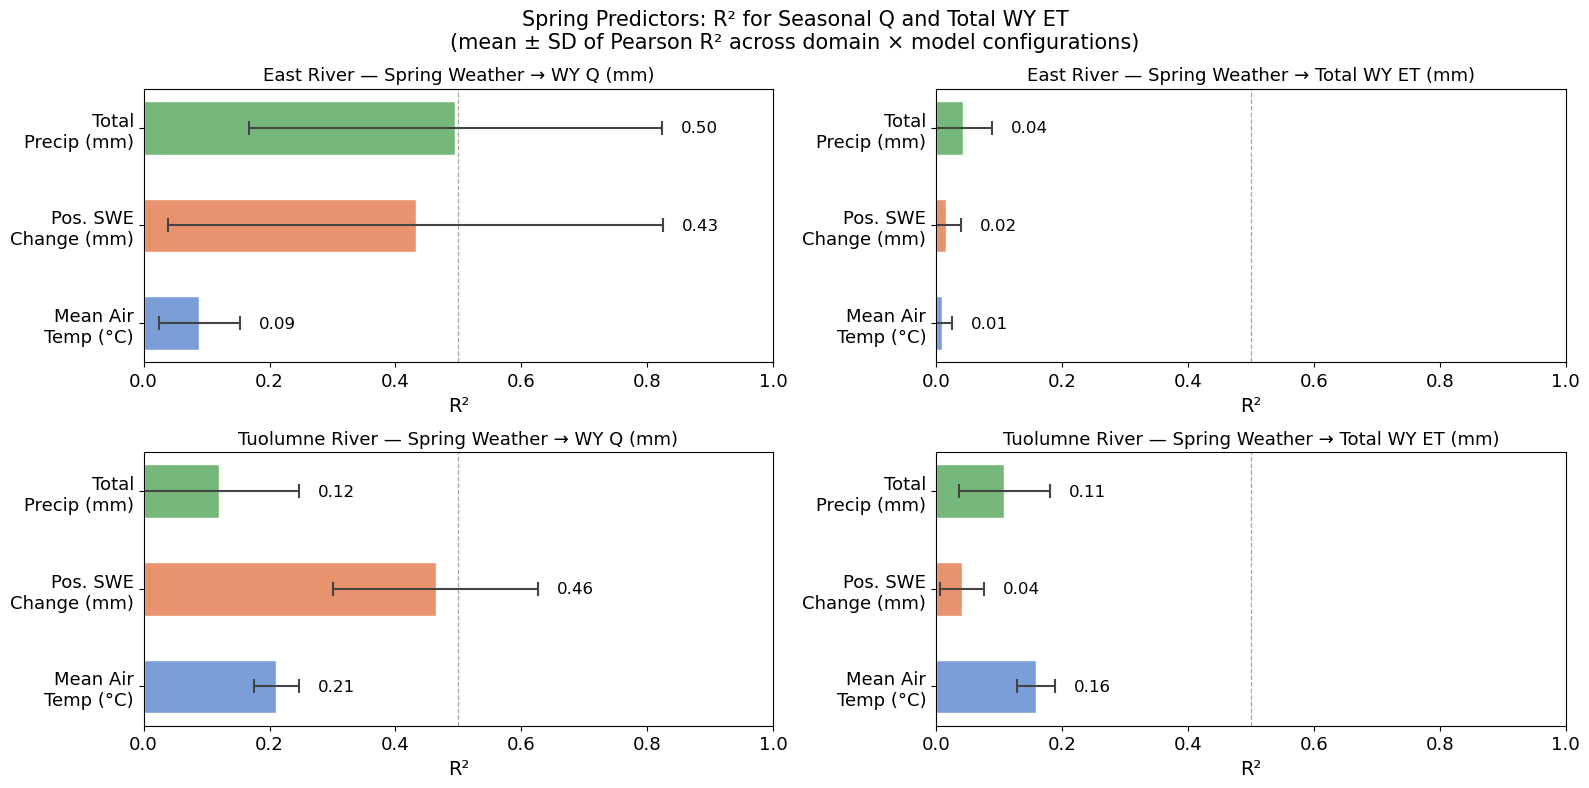

In [45]:
# ============================================================
# 7. Spring Predictors → R² for Seasonal Q and Total WY ET
# ============================================================
# "Total WY ET" = sum of total_et_sublim_mm across all 4 seasons per donor year.
# Spring predictors (SWE change, temp, precip) correlated with spring Q and WY-total ET.
# R² computed per (basin, model) combination, then mean ± std across models shown.
# Note: sublimation is included in total_et_sublim_mm but is a minor fraction.

wy_et = (
    df.groupby(['basin', 'model', 'donor_wy'], observed=True)['total_et_sublim_mm']
    .sum()
    .reset_index()
    .rename(columns={'total_et_sublim_mm': 'total_wy_et_mm'})
)

spring_wy = (
    df[df['season'] == 'spring'][[
        'basin', 'spatial', 'model', 'donor_wy',
        'pos_swe_change_mm', 'mean_airtemp_C', 'total_p_mm', 'total_q_mm'
    ]]
    .merge(wy_et, on=['basin', 'model', 'donor_wy'])
)

PREDICTORS_SP = [
    ('pos_swe_change_mm', 'Pos. SWE\nChange (mm)'),
    ('mean_airtemp_C',    'Mean Air\nTemp (°C)'),
    ('total_p_mm',        'Total\nPrecip (mm)'),
]
RESPONSES_WY = [
    ('total_q_mm',     'WY Q (mm)'),
    ('total_wy_et_mm', 'Total WY ET (mm)'),
]

# Compute r² per (basin, model) — square first, then aggregate for unbiased mean
corr_wy_rows = []
for (basin, model), grp in spring_wy.groupby(['basin', 'model'], observed=True):
    for pred_col, pred_label in PREDICTORS_SP:
        for resp_col, resp_label in RESPONSES_WY:
            sub = grp[[pred_col, resp_col]].dropna()
            if len(sub) < 6:
                continue
            r, _ = stats.pearsonr(sub[pred_col], sub[resp_col])
            corr_wy_rows.append({
                'basin': basin, 'model': model,
                'predictor': pred_label, 'response': resp_label,
                'r2': r ** 2,
            })

corr_wy_df = pd.DataFrame(corr_wy_rows)

r2_wy = (
    corr_wy_df.groupby(['basin', 'predictor', 'response'])['r2']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'R2', 'std': 'R2_std'})
)

PRED_COLORS = ['#7B9ED9', '#E8936E', '#76B77B']

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, (resp_col, resp_label) in enumerate(RESPONSES_WY):
        ax = axes[row_i, col_i]
        sub = r2_wy[(r2_wy['basin'] == basin) & (r2_wy['response'] == resp_label)]
        preds = sub['predictor'].tolist()
        vals  = sub['R2'].tolist()
        errs  = sub['R2_std'].tolist()
        bars = ax.barh(preds, vals, xerr=errs, color=PRED_COLORS[:len(preds)],
                       edgecolor='white', height=0.55,
                       error_kw=dict(ecolor='#444444', capsize=5, capthick=1.5, elinewidth=1.5))
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color='gray', lw=0.9, ls='--', alpha=0.7)
        ax.set_xlabel('R²', fontsize=14)
        ax.set_title(f'{basin.replace("_", " ")} — Spring Weather → {resp_label}', fontsize=13)
        ax.tick_params(labelsize=13)
        for bar, val, err in zip(bars, vals, errs):
            x_ann = min(val + err + 0.03, 0.93)
            ax.text(x_ann, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}', va='center', fontsize=12)

plt.suptitle('Spring Predictors: R² for Seasonal Q and Total WY ET\n'
             '(mean ± SD of Pearson R² across domain × model configurations)', fontsize=15)
plt.tight_layout()
plt.savefig('ess-project/figures/fig_spring_r2_wy_et.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import xarray as xr

# ============================================================
# 8a. End-of-Spring (June 30) Storage — read from ensemble outputs
# ============================================================
# For each domain × model × donor_wy spring simulation, extract the last
# timestep of scalarSWE, scalarTotalSoilLiq, and scalarAquiferStorage_mean
# (aquifer in meters; multiply ×1000 for mm). Results are cached to CSV.
# Note: aquifer storage for noXplict/qTopmodl is set to 0 (no explicit bucket).

STORAGE_CACHE = Path('ess-project/results/spring_storage_june30.csv')

def _area_weighted_mean(da, hru_areas):
    """Scalar area-weighted mean of a single-timestep DataArray (hru dim)."""
    vals = da.values.squeeze()
    if hru_areas is not None and 'hru' in da.dims:
        w = hru_areas.values / hru_areas.values.sum()
        return float((vals * w).sum())
    return float(vals.mean())

if STORAGE_CACHE.exists():
    spring_storage_df = pd.read_csv(STORAGE_CACHE)
    print(f'Loaded storage cache: {len(spring_storage_df):,} rows')
else:
    # Load HRU areas from attribute files
    hru_areas_cache = {}
    for domain in DOMAIN_REGISTRY:
        attr_path = DATA_DIR / f'domain_{domain}' / 'settings' / 'SUMMA' / 'attributes.nc'
        if attr_path.exists():
            with xr.open_dataset(attr_path) as attrs:
                hru_areas_cache[domain] = attrs['HRUarea'].load()
        else:
            print(f'  Warning: attr file missing for {domain}')

    storage_rows = []
    for domain, meta in DOMAIN_REGISTRY.items():
        ens_dir = DATA_DIR / f'domain_{domain}' / 'simulations' / 'seasonal_ensemble_simulations'
        hru_areas = hru_areas_cache.get(domain)
        for model in meta['models']:
            for wy in range(2001, 2021):
                nc_path = (ens_dir / model / 'spring_simulations'
                           / f'donor_{wy}' / 'output'
                           / f'seasonal_spring_d{wy}_timestep.nc')
                if not nc_path.exists():
                    continue
                try:
                    with xr.open_dataset(nc_path) as ds:
                        swe_da  = ds['scalarSWE'].isel(time=-1)       if 'scalarSWE'          in ds else None
                        soil_da = ds['scalarTotalSoilLiq'].isel(time=-1) if 'scalarTotalSoilLiq' in ds else None
                        aq_var  = next((v for v in ['scalarAquiferStorage_mean', 'scalarAquiferStorage']
                                        if v in ds), None)
                        aq_da   = ds[aq_var].isel(time=-1) if aq_var else None

                        swe_mm  = _area_weighted_mean(swe_da,  hru_areas) if swe_da  is not None else 0.0
                        soil_mm = _area_weighted_mean(soil_da, hru_areas) if soil_da is not None else 0.0
                        aq_mm   = _area_weighted_mean(aq_da,   hru_areas) * 1000 if aq_da is not None else 0.0

                    storage_rows.append({
                        'domain': domain, 'model': model, 'donor_wy': wy,
                        'swe_mm': swe_mm, 'soil_liq_mm': soil_mm, 'aquifer_mm': aq_mm,
                        'total_storage_mm': swe_mm + soil_mm + aq_mm,
                    })
                except Exception as e:
                    print(f'  Warning: {domain}/{model}/donor_{wy}: {e}')

    spring_storage_df = pd.DataFrame(storage_rows)
    spring_storage_df['basin']   = spring_storage_df['domain'].map({d: m['basin']   for d, m in DOMAIN_REGISTRY.items()})
    spring_storage_df['spatial'] = spring_storage_df['domain'].map({d: m['spatial'] for d, m in DOMAIN_REGISTRY.items()})
    spring_storage_df['spatial'] = pd.Categorical(spring_storage_df['spatial'], categories=SPATIAL_ORDER, ordered=True)
    spring_storage_df['model']   = pd.Categorical(spring_storage_df['model'],   categories=MODEL_ORDER,   ordered=True)

    STORAGE_CACHE.parent.mkdir(parents=True, exist_ok=True)
    spring_storage_df.to_csv(STORAGE_CACHE, index=False)
    print(f'Storage cache written: {len(spring_storage_df):,} rows')

# Merge storage into a spring predictor dataframe with all 5 predictors
spring_wy_s = (
    df[df['season'] == 'spring'][[
        'domain', 'basin', 'spatial', 'model', 'donor_wy',
        'total_p_mm', 'total_snowfall_mm', 'mean_airtemp_C',
        'total_et_sublim_mm', 'total_q_mm',
    ]]
    .merge(
        spring_storage_df[['domain', 'model', 'donor_wy',
                            'swe_mm', 'soil_liq_mm', 'aquifer_mm', 'total_storage_mm']],
        on=['domain', 'model', 'donor_wy'], how='left'
    )
)

print(spring_storage_df.groupby('model')[['swe_mm','soil_liq_mm','aquifer_mm']].mean().round(1))
spring_storage_df.head(3)

In [ ]:
# ============================================================
# 8b. Stacked Bar: End-of-Spring Storage — bigBuckt Models
# ============================================================
# Shows how June 30 storage is partitioned into SWE / soil liquid / aquifer
# for each bigBuckt configuration across 20 donor water years.
# (noXplict/qTopmodl excluded: no explicit aquifer bucket.)

STOR_COLORS = {'SWE': '#5B8DB8', 'Soil Liq': '#76B77B', 'Aquifer': '#C4956A'}
SPATIAL_LABELS_B = {'lumped': 'Lumped', 'elev': 'Elev', 'elevAspect': 'Elev+Aspect', 'elevTPI': 'Elev+TPI'}

bb_stor = (spring_storage_df[spring_storage_df['model'] == 'bigBuckt']
           .sort_values('donor_wy'))

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey='row')
for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, spatial in enumerate(SPATIAL_ORDER):
        ax = axes[row_i, col_i]
        sub = bb_stor[(bb_stor['basin'] == basin) & (bb_stor['spatial'] == spatial)]
        if sub.empty:
            ax.set_visible(False)
            continue
        x = np.arange(len(sub))
        swe  = sub['swe_mm'].values
        soil = sub['soil_liq_mm'].values
        aq   = sub['aquifer_mm'].values
        ax.bar(x, swe,  color=STOR_COLORS['SWE'],      label='SWE',      width=0.7)
        ax.bar(x, soil, color=STOR_COLORS['Soil Liq'], label='Soil Liq', width=0.7, bottom=swe)
        ax.bar(x, aq,   color=STOR_COLORS['Aquifer'],  label='Aquifer',  width=0.7, bottom=swe + soil)
        wys = sub['donor_wy'].values
        ax.set_xticks(x[::4])
        ax.set_xticklabels(wys[::4], rotation=45, ha='right', fontsize=9)
        ax.set_title(SPATIAL_LABELS_B[spatial], fontsize=11)
        if col_i == 0:
            ax.set_ylabel(f'{basin.replace("_", " ")}\nStorage (mm)', fontsize=10)
        ax.tick_params(labelsize=9)

handles = [mpatches.Patch(color=c, label=l) for l, c in STOR_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.03))
plt.suptitle('End-of-Spring (June 30) Storage by Donor Year — bigBuckt Models\n'
             'SWE + Soil Liquid + Aquifer (area-weighted basin mean)', fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('ess-project/figures/fig_spring_storage_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 8c. R² Heatmap: Spring Predictors → Spring Q
# ============================================================
# Each cell = Pearson R² across 20 donor years for one (spatial, model) combo.
# Layout: 2 rows (basins) × 5 cols (predictors).
# Within each panel: y = spatial discretization (lumped bottom → elevTPI top),
#                    x = subsurface model (bigBuckt left → qTopmodl right).

PREDICTORS_H = [
    ('total_p_mm',         'Spring\nPrecip'),
    ('total_snowfall_mm',  'Spring\nSnowfall'),
    ('mean_airtemp_C',     'Spring\nTemp (°C)'),
    ('total_et_sublim_mm', 'Spring\nET+Sublim'),
    ('total_storage_mm',   'June 30\nStorage'),
]
SPATIAL_ABBR = {
    'lumped': 'Lumped', 'elev': 'Elev',
    'elevAspect': 'Elev+\nAspect', 'elevTPI': 'Elev+\nTPI',
}

r2_heat_rows = []
for (basin, spatial, model), grp in spring_wy_s.groupby(['basin', 'spatial', 'model'], observed=True):
    for pred_col, pred_label in PREDICTORS_H:
        sub = grp[['total_q_mm', pred_col]].dropna()
        if len(sub) < 6:
            continue
        r, _ = stats.pearsonr(sub[pred_col], sub['total_q_mm'])
        r2_heat_rows.append({
            'basin': basin, 'spatial': spatial, 'model': model,
            'predictor': pred_label, 'r2': r ** 2,
        })

r2_heat_df = pd.DataFrame(r2_heat_rows)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row_i, basin in enumerate(['East_River', 'Tuolumne_River']):
    for col_i, (pred_col, pred_label) in enumerate(PREDICTORS_H):
        ax = axes[row_i, col_i]
        sub = r2_heat_df[(r2_heat_df['basin'] == basin) & (r2_heat_df['predictor'] == pred_label)]
        pivot = sub.pivot_table(index='spatial', columns='model', values='r2')
        # Reverse spatial order so lumped is at bottom of heatmap (seaborn draws top→down)
        spatial_avail = [s for s in reversed(SPATIAL_ORDER) if s in pivot.index]
        model_avail   = [m for m in MODEL_ORDER if m in pivot.columns]
        pivot = pivot.reindex(index=spatial_avail, columns=model_avail)
        pivot.index = [SPATIAL_ABBR.get(s, s) for s in spatial_avail]
        sns.heatmap(pivot, ax=ax, cmap='YlGnBu', annot=True, fmt='.2f',
                    linewidths=0.5, vmin=0, vmax=1, cbar=False,
                    annot_kws={'size': 9})
        if row_i == 0:
            ax.set_title(pred_label, fontsize=11)
        ax.set_ylabel('Spatial Discr.' if col_i == 0 else '', fontsize=10)
        ax.set_xlabel('Subsurface Model' if row_i == 1 else '', fontsize=10)
        if col_i == 0:
            ax.set_ylabel(f'{basin.replace("_", " ")}\nSpatial Discr.', fontsize=10)
        ax.tick_params(labelsize=9)

# Shared colorbar
fig.subplots_adjust(right=0.91)
cbar_ax = fig.add_axes([0.93, 0.15, 0.014, 0.7])
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax).set_label('R²', fontsize=11)

plt.suptitle('Spring Predictors: R² for Spring Q\n'
             '(Pearson R² across 20 donor years — each cell = one spatial × subsurface configuration)',
             fontsize=13)
plt.savefig('ess-project/figures/fig_spring_r2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()